In [7]:
from pathlib import Path

# enable ipympl widgets for zoom
%matplotlib widget 
import seaborn as sns
import matplotlib.pyplot as plt
#from matplotlib.ticker import FixedLocator
from matplotlib.ticker import AutoMinorLocator
import pandas as pd
import pint_pandas  # needed for initialization

In [8]:
sns.set_theme()

In [9]:
def import_dataset(filename: Path):
    df = pd.read_csv(filename, header=[0, 1])

    names = df.columns.get_level_values(0)
    units = df.columns.get_level_values(1)

    df.columns = names  # flatten
    if 'timestamp' in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"], format="ISO8601")
    for col, unit in zip(names, units):  # apply units
        if unit != "No Unit":
            df[col] = df[col].astype(f"pint[{unit}]")

    return df

In [10]:
def import_measurements(run_folder: Path):
    filename = run_folder / "multimeter.csv"
    df = import_dataset(filename)
    return df

In [11]:
def import_markers(run_folder: Path):
    filename = run_folder / "markers.csv"
    df = import_dataset(filename)
    start = df.loc[df["kind"] == "START", "timestamp"].iloc[0]
    end = df.loc[df["kind"] == "END", "timestamp"].iloc[0]
    return start, end

In [12]:
def import_data(run_folder: Path):
    df = import_measurements(run_folder)
    start, end = import_markers(run_folder)
    return df, start, end

In [13]:
#experiment_folder = Path("../power_measurement/experiment")
image_folder = Path.cwd() / "resources/images"
image_folder.mkdir(parents=True, exist_ok=True)
experiment_folder = Path("../data_aggregator")
resources_folder = experiment_folder / "raw_resources/normalize_test3"
host = "radxax4"
tag_name = "bzip3_compress_sensor_default_single"
data = import_data(resources_folder / f"radxax4_bzip3/{host}/{tag_name}/run_016")

In [14]:
df = data[0]
t0 = df["timestamp"].iloc[0]

df_plot = df.copy()
df_plot["relative_time_s"] = (
    df_plot["timestamp"] - t0
).dt.total_seconds()

start_rel_s = (data[1] - t0).total_seconds()
end_rel_s = (data[2] - t0).total_seconds()

df_plot["current_A"] = df_plot["current"].pint.magnitude
df_plot["voltage_V"] = df_plot["voltage"].pint.magnitude

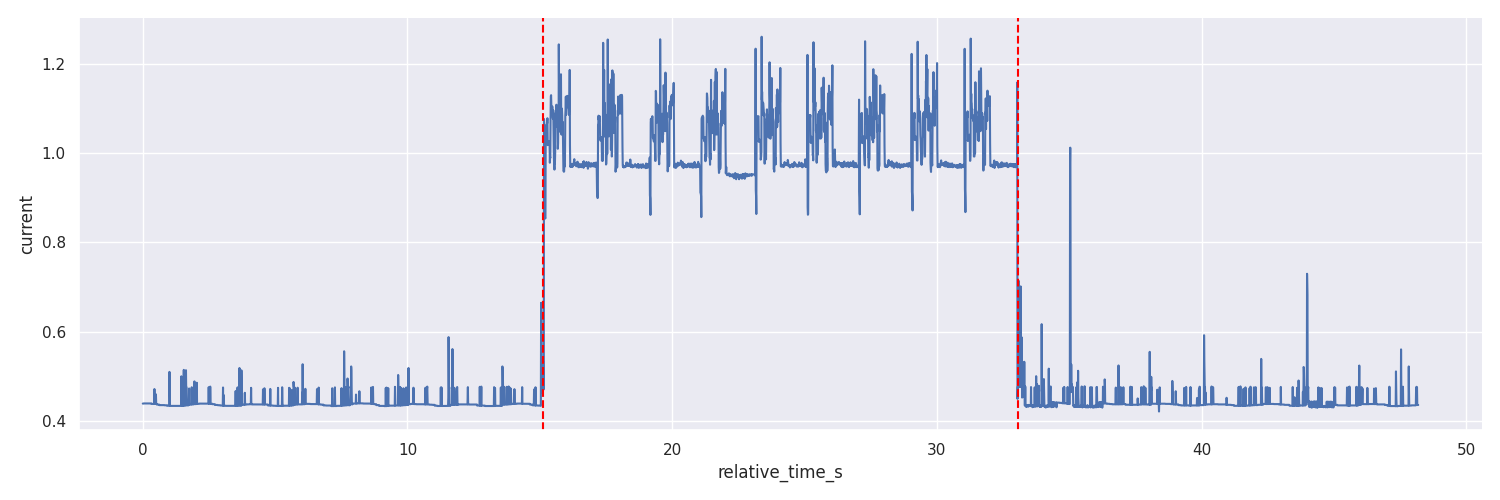

In [15]:
g = sns.relplot(data=df_plot,
            x="relative_time_s", y="current", 
            #hue="tag",
            kind="line",
            aspect=3,
           )
g.ax.axvline(x=start_rel_s, color="red", linestyle="--")
g.ax.axvline(x=end_rel_s, color="red", linestyle="--")
plt.show()

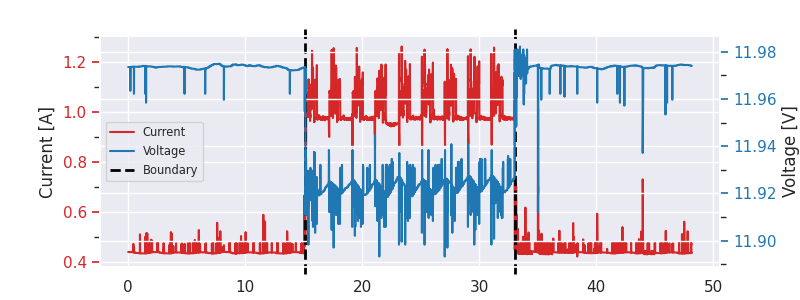

In [16]:
fig, ax1 = plt.subplots(figsize=(8, 3))

line1 = ax1.plot(df_plot["relative_time_s"], df_plot["current_A"], label="Current", color="tab:red")
ax1.set_ylabel("Current [A]")
ax1.tick_params(axis="y", colors="tab:red")

ax2 = ax1.twinx()
line2 = ax2.plot(df_plot["relative_time_s"], df_plot["voltage_V"], label="Voltage", color="tab:blue")
ax2.set_ylabel("Voltage [V]")
ax2.tick_params(axis="y", colors="tab:blue")

ax1.axvline(start_rel_s, color="black", linestyle="--", linewidth=2, zorder=10, 
    ymin=-0.03,
    ymax=1.03,
    clip_on=False,
    label="Boundary",
)
ax1.axvline(end_rel_s, color="black", linestyle="--", linewidth=2, zorder=10,
    ymin=-0.03,
    ymax=1.03,
    clip_on=False,
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

handles = lines1 + lines2
labels = labels1 + labels2

boundary_idx = labels.index("Boundary")
boundary_handle = handles.pop(boundary_idx)
boundary_label = labels.pop(boundary_idx)
handles.append(boundary_handle)
labels.append(boundary_label)

legend = ax2.legend(
    handles,
    labels,
    fontsize="x-small",
    loc="center left",
)
#ax2.legend()

ax1.yaxis.set_minor_locator(AutoMinorLocator(2))
ax2.yaxis.set_minor_locator(AutoMinorLocator(2))

#ax1.xaxis.set_minor_locator(FixedLocator([start_rel_s]))
#ax1.tick_params(axis="x", which="minor", length=8, width=2)
#ax1.annotate(
#    "Start",
#    xy=(start_rel_s, 0),
#    xycoords=("data", "axes fraction"),
#    xytext=(0, -20),
#    textcoords="offset points",
#    ha="center",
#    color="black",
#)
#ax1.text(
#    start_rel_s,
#    1.05,
#    "Start",
#    transform=ax1.get_xaxis_transform(),
#    color="black",
#    ha="center",
#    va="top",
#)
#ax1.text(
#    end_rel_s,
#    1.05,
#    "End",
#    transform=ax1.get_xaxis_transform(),
#    color="black",
#    ha="center",
#    va="top",
#)
#print("generate: %s" % (image_folder / f"raw_{tag_name}.pdf"))
fig.savefig(image_folder / f"raw_{host}_{tag_name}.pdf", bbox_inches="tight")
fig.canvas.draw()
plt.show()

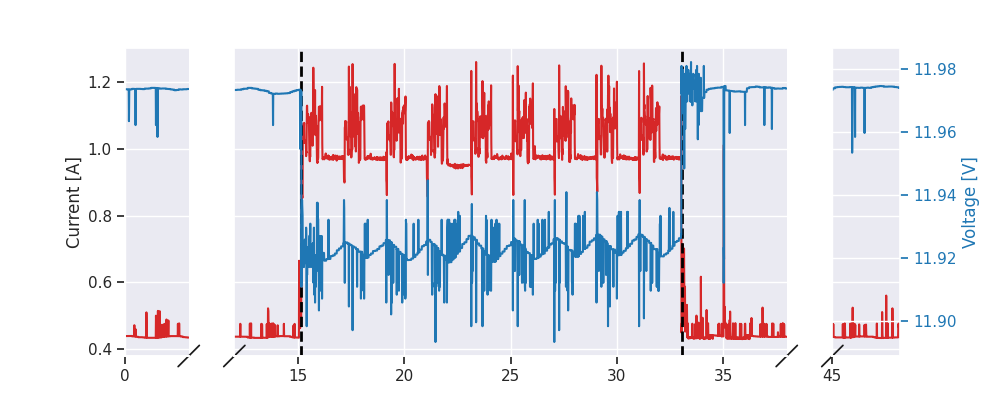

In [21]:
fig = plt.figure(figsize=(10, 4))

bax = brokenaxes(
    xlims=((0, 3), (12, 38), (45, df_plot["relative_time_s"].max())),
    hspace=0.05
)

# Current
bax.plot(
    df_plot["relative_time_s"],
    df_plot["current_A"],
    color="tab:red",
)

# Voltage on secondary y-axis
for i, ax in enumerate(bax.axs):
    ax2 = ax.twinx()

    ax2.plot(
        df_plot["relative_time_s"],
        df_plot["voltage_V"],
        color="tab:blue",
    )

    if i == len(bax.axs) - 1:
        ax2.set_ylabel("Voltage [V]", color="tab:blue")
        ax2.tick_params(axis="y", colors="tab:blue")
    else:
        ax2.set_yticks([])
        ax2.spines["right"].set_visible(False)

# Primary y-axis label
bax.set_ylabel("Current [A]")

# Vertical markers
for x in [start_rel_s, end_rel_s]:
    bax.axvline(
        x,
        color="black",
        linestyle="--",
        linewidth=2
    )

plt.show()

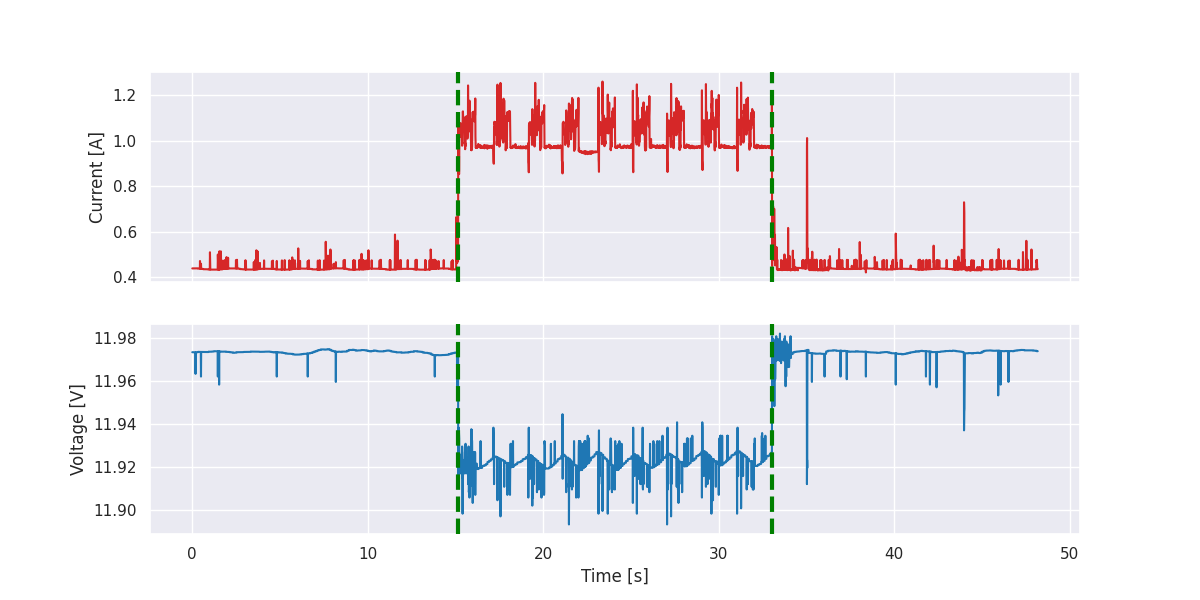

In [11]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(12, 6)
)

ax1.plot(df_plot["relative_time_s"], df_plot["current_A"], color="tab:red")
ax1.set_ylabel("Current [A]")

ax2.plot(df_plot["relative_time_s"], df_plot["voltage_V"], color="tab:blue")
ax2.set_ylabel("Voltage [V]")
ax2.set_xlabel("Time [s]")

ax1.axvline(start_rel_s, color="green", linestyle="--", linewidth=3, zorder=10)
ax1.axvline(end_rel_s, color="green", linestyle="--", linewidth=3, zorder=10)

ax2.axvline(start_rel_s, color="green", linestyle="--", linewidth=3, zorder=10)
ax2.axvline(end_rel_s, color="green", linestyle="--", linewidth=3, zorder=10)


plt.show()